# Linear spectral unmixing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from utils import objective_function, generate_abundance_map, compute_rmse, compute_fcls
from viz import plot_endmember_spectral_signatures, plot_abundance_maps, nice_colorbar

## Problem set-up: endmember spectra and available wavelengths

In [3]:
# [Known] Wavelength values, of shape (nb_wavelengths,)
wavelengths = [80, 125, 550, 700, 1350, 1700]
nb_wavelengths = len(wavelengths)

In [4]:
# [Known] Endmembers spectra, of shape (nb_wavelengths,)
endmember_alpha = np.array([0.02, 0.08, 0.04, 0.7, 0.2, 0.05])
endmember_beta = np.array([0.05, 0.1, 0.15, 0.3, 0.4, 0.35])
endmember_gamma = np.array([0.2, 0.22, 0.25, 0.24, 0.15, 0.1])
labels = ['Alpha (Vegetation)', 'Beta (Soil)', 'Gamma (Concrete)']
nb_endmembers = len(labels)

In [5]:
# [Known] Endmember matrix M, of shape (nb_wavelengths, nb_endmembers)
endmember_matrix = np.stack((endmember_alpha, endmember_beta, endmember_gamma), axis=1)
print(endmember_matrix)

[[0.02 0.05 0.2 ]
 [0.08 0.1  0.22]
 [0.04 0.15 0.25]
 [0.7  0.3  0.24]
 [0.2  0.4  0.15]
 [0.05 0.35 0.1 ]]


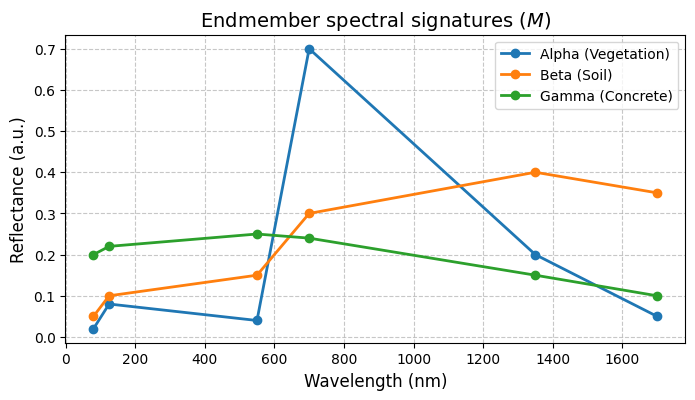

In [6]:
plot_endmember_spectral_signatures(endmember_matrix=endmember_matrix, wavelengths=wavelengths, labels=labels)    

## Existence and uniqueness of a solution and numerical stability

### Rank

The matrix rank identifies the number of linearly independent dimensions in the spectral collection. 

- If the rank is equal to the number of columns (endmembers), the endmember spectra is linearly independent, and there exists a unique solution to the unmixing problem.
- Unmixing becomes a *well-posed* problem if it respects the Hadamard criteria (existence, uniqueness, and stability). The rank is indicative on the two first criteria, the *condition number* is indicative of the third.
- If the rank is lower than the number of endmembers, it means that some spectra are linearly dependent. This redundancy makes the system is underdetermined, and the unmixing problem has infinitly many solutions.


### Singular Values

Singular values describe the relative strength of the independent directions in spectral space. While the matrix rank only indicates the number of linearly independent dimensions, the singular values provide a finer characterization of their numerical stability. If the smallest singular value approaches zero, the matrix becomes nearly rank-deficient, and the inversion problem becomes highly sensitive to noise.

### Condition number

The condition number measures how sensitive the solution is to small changes or noise in the input data.

- The condition number is equal to the quotient of the largest singular value by the smallest singular value.
- A small condition number indicate that the endmembers are nearly orthogonal and that the unmixing will be stable (a minor change in the input will only cause a minor change in the output).
- A high condition number (often caused by nearly identical spectral signatures) warns that even tiny sensor errors will lead to massive, physically unrealistic fluctuations in the calculated abundances.

In [7]:
rank = np.linalg.matrix_rank(endmember_matrix)
singular_values = np.linalg.svd(endmember_matrix, compute_uv=False)
condition_number = np.linalg.cond(endmember_matrix)

print(f"Rank: {rank}")
print(f"Singular values: {singular_values}")
print(f"Condition number: {condition_number:.2f}")

Rank: 3
Singular values: [0.9783073  0.39869899 0.27083934]
Condition number: 3.61


## Measurements

In [8]:
# [Unknown] Abundance map
map_height = 7
map_width = 9
nb_pixels = map_height * map_width
abundance_map = generate_abundance_map(height=map_height, width=map_width, nb_endmembers=nb_endmembers)

In [9]:
# [Known] Observed spectra
abundance_map_flat = abundance_map.reshape(-1, nb_endmembers)
measurement_noise =  np.random.normal(0, 0.01, size=(abundance_map_flat.shape[0], endmember_matrix.shape[0]))
observed_spectra_flat = abundance_map_flat @ endmember_matrix.T + measurement_noise
observed_spectra = observed_spectra_flat.reshape(map_height, map_width, -1)

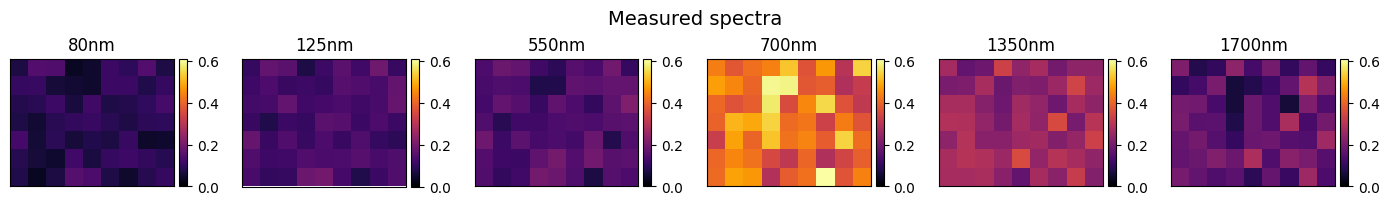

In [10]:
fig, axes = plt.subplots(1, nb_wavelengths, figsize=(14, 2))
plt.suptitle("Measured spectra", fontsize=14)
for w in range(nb_wavelengths):

    ax = axes[w]
    im = ax.imshow(observed_spectra[:,:,w], cmap="inferno", vmin=0, vmax=np.max(observed_spectra))
    nice_colorbar(im=im, ax=ax)
    
    ax.set_title(f"{wavelengths[w]}nm", fontsize=12)        
    ax.set_xticks([]);
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Solution found by means of iterative least squares minimization (iSLSQP)

In [11]:
# Minimization of ||Ma - y||^2, subject to sum(a)=1 and a>=0.
constraints = ({"type": "eq", "fun": lambda a: np.sum(a) - 1}) # Sum to 1
bounds = ((0, 1), (0, 1), (0, 1)) # Non-negative and capped at 1

estimated_abundances_islsqp_flat = np.zeros_like(abundance_map_flat)
for i in range(nb_pixels):
    res = minimize(
        objective_function,
        x0=[1/3, 1/3, 1/3],
        args=(endmember_matrix, observed_spectra_flat[i]),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    estimated_abundances_islsqp_flat[i] = res.x

abundance_map_estimated_islsqp = estimated_abundances_islsqp_flat.reshape(map_height, map_width, nb_endmembers)

abundance_map_error_islsqp = abundance_map - abundance_map_estimated_islsqp

rmse_islsqp = compute_rmse(prediction=abundance_map_estimated_islsqp, ground_truth=abundance_map)
print(f"RMSE: {rmse_islsqp:.4f}")

RMSE: 0.0214


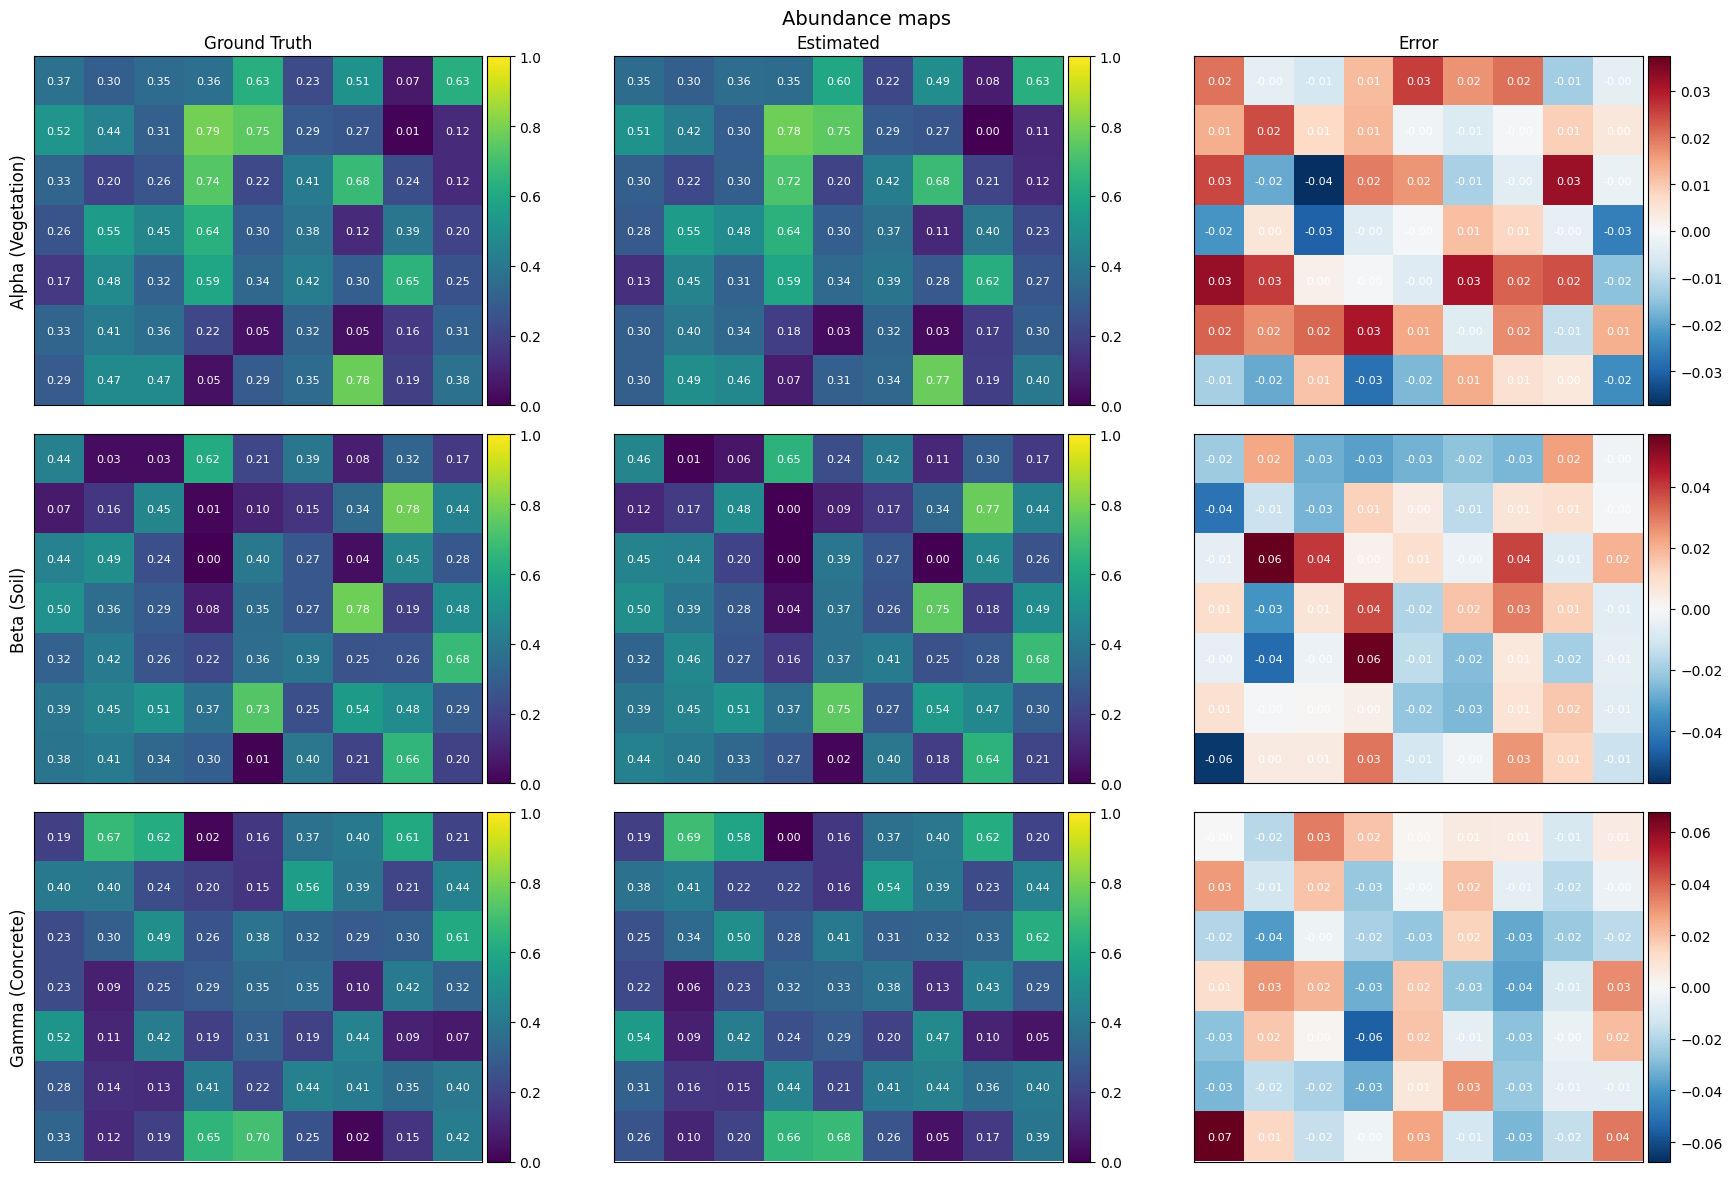

In [12]:
plot_abundance_maps(abundance_map, abundance_map_estimated_islsqp, abundance_map_error_islsqp, labels)

## Solution found by means of fully constrained least squares (FCLS)

In [13]:
estimated_abundances_fcls_flat = np.zeros_like(abundance_map_flat)
for i in range(nb_pixels):
    estimated_abundances_fcls_flat[i] = compute_fcls(spectrum=observed_spectra_flat[i], M=endmember_matrix)

abundance_map_estimated_fcls = estimated_abundances_fcls_flat.reshape(map_height, map_width, nb_endmembers)

abundance_map_error_fcls = abundance_map - abundance_map_estimated_fcls

rmse_fcls = compute_rmse(prediction=abundance_map_estimated_fcls, ground_truth=abundance_map)
print(f"RMSE: {rmse_fcls:.4f}")

RMSE: 0.0215


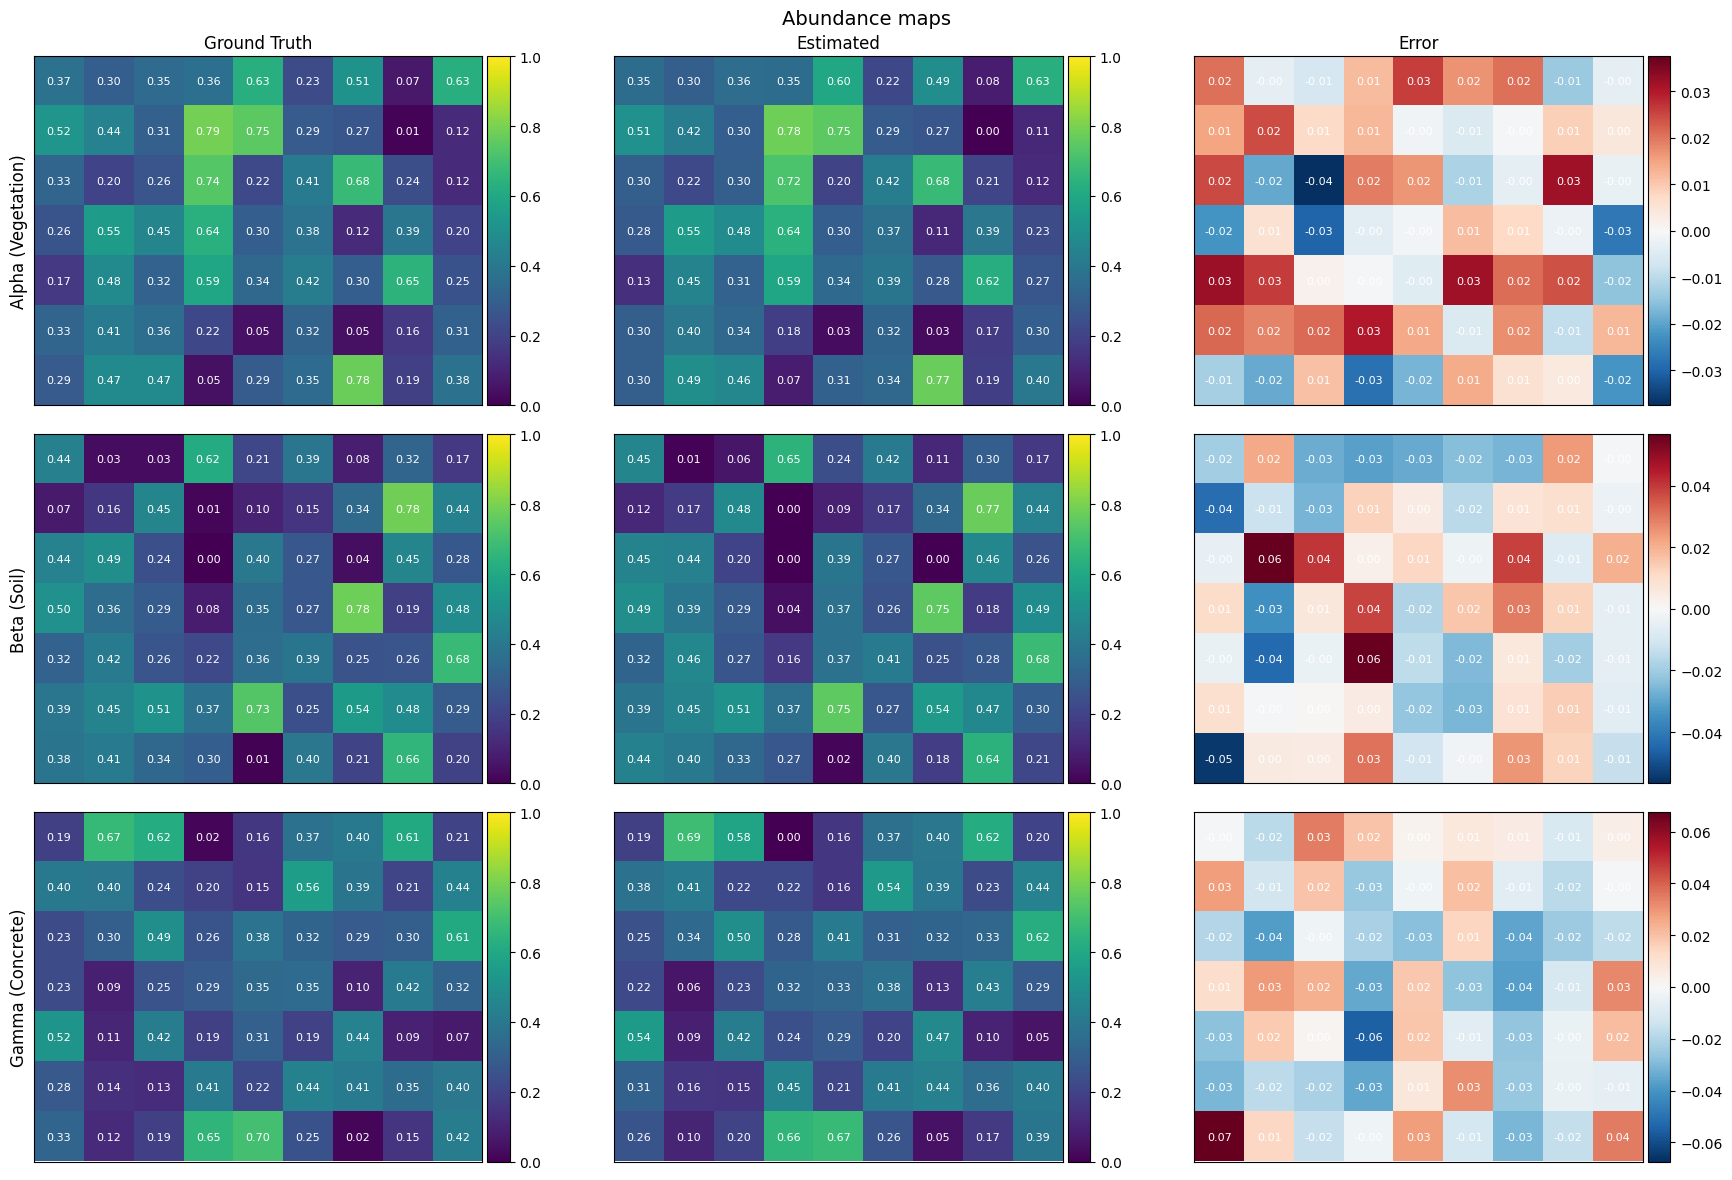

In [14]:
plot_abundance_maps(abundance_map, abundance_map_estimated_fcls, abundance_map_error_fcls, labels)